# Merchant ETL

In [1]:
# libraries
import sys, os, glob
from pyspark.sql import SparkSession
import zipfile
import pandas as pd
from pyspark.sql.types import StructType, StructField, LongType, DoubleType, DateType, StringType, IntegerType
from pyspark.sql import functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/18 16:47:37 WARN Utils: Your hostname, CompuPau, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/18 16:47:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/pau_l/MAST30034_Python/.venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/18 16:47:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/18 16:47:38 WARN Utils: Service 'SparkUI' c

In [3]:
# Unzip the data files
zip_file_path = [
    "../data/project-2-bnpl-tables-part1.zip",
    "../data/project-2-bnpl-tables-part2.zip",
    "../data/project-2-bnpl-tables-part3.zip",
    "../data/project-2-bnpl-tables-part4.zip"
]

for zip_path in zip_file_path:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("../data/")

In [4]:
# helper function to peek at a Spark DataFrame
def peek(df, n=5):
    # print n heads and total number of rows of a Spark DataFrame
    total = df.count()
    df.show(n, truncate=False)
    print(f"-> {total} rows total")

## Load raw tables

In [5]:
merchants_raw = spark.read.parquet("../data/tables/tbl_merchants.parquet")

fraud_schema = StructType([
    StructField("merchant_abn", LongType(), True),
    StructField("order_datetime", DateType(), True),
    StructField("fraud_probability", DoubleType(), True),
])
merchant_fraud = spark.read.csv(
    "../data/tables/merchant_fraud_probability.csv",
    schema=fraud_schema,
    header=True
)

peek(merchants_raw)
peek(merchant_fraud)

+------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------+
|name                                |tags                                                                                                             |merchant_abn|
+------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------+
|Felis Limited                       |((furniture, home furnishings and equipment shops, and manufacturers, except appliances), (e), (take rate: 0.18))|10023283211 |
|Arcu Ac Orci Corporation            |([cable, satellite, and otHer pay television and radio services], [b], [take rate: 4.22])                        |10142254217 |
|Nunc Sed Company                    |([jewelry, watch, clock, and silverware shops], [b], [take rate: 4.40])                                          |10165489824 |
|Ult

## Parse merchant tags

In [6]:
# 3 columns of interest in the `tags` column: category, revenue band, and take rate
tag_pattern = r'[\(\[](.+?)[\)\]],\s*[\(\[]([a-eA-E])[\)\]],\s*[\(\[]take rate:\s*([\d.]+)[\)\]]'

merchants_parsed = (
    merchants_raw
    .withColumn("category_raw", F.regexp_extract("tags", tag_pattern, 1))
    .withColumn("revenue_band_raw", F.regexp_extract("tags", tag_pattern, 2))
    .withColumn("take_rate_raw", F.regexp_extract("tags", tag_pattern, 3))
    .withColumn("category",
                F.regexp_replace(
                F.lower(F.trim(F.regexp_replace("category_raw", r'^[\[\(\{|\[\)\]]+|[\[\(\{|\[\)\]]+$', ''))),
                r'\s+', ' '))
    .withColumn("revenue_band", F.when(F.col("revenue_band_raw") == "", None).otherwise(F.lower(F.col("revenue_band_raw"))))
    .withColumn("take_rate", F.when(F.col("take_rate_raw") == "", None).otherwise(F.col("take_rate_raw").cast(DoubleType())))
    .drop("category_raw", "revenue_band_raw", "take_rate_raw")
)

peek(merchants_parsed)

+------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------+-------------------------------------------------------------------------------------+------------+---------+
|name                                |tags                                                                                                             |merchant_abn|category                                                                             |revenue_band|take_rate|
+------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------+-------------------------------------------------------------------------------------+------------+---------+
|Felis Limited                       |((furniture, home furnishings and equipment shops, and manufacturers, except appliances), (e), (take rate: 0.18))|10023283211 |furniture,

In [7]:
merchants_parsed.select("category").distinct().orderBy("category").show(200, truncate=False)

+-------------------------------------------------------------------------------------+
|category                                                                             |
+-------------------------------------------------------------------------------------+
|antique shops - sales, repairs, and restoration services                             |
|art dealers and galleries                                                            |
|artist supply and craft shops                                                        |
|bicycle shops - sales and service                                                    |
|books, periodicals, and newspapers                                                   |
|cable, satellite, and other pay television and radio services                        |
|computer programming , data processing, and integrated systems design services       |
|computers, computer peripheral equipment, and software                               |
|digital goods: books, movies, m

In [8]:
category_groups = {
    "antiques_art_craft":       ["antique shop", "art dealer", "art galler", "artist supply", "craft shop"],
    "equipment_rental_leasing": ["rental and leasing", "appliance rent"],
    "furniture_home":           ["furniture, home furnishing"],
    "vehicle":                  ["bicycle shop", "motor vehicle"],
    "books_media_digital":      ["periodicals", "newspaper", "digital goods"],
    "tv_media_telecom":         ["cable,", "satellite", "television", "telecom"],
    "technology":               ["computer programming", "data processing", "computer peripheral", "computers,"],
    "gardening":                ["florist", "nursery", "lawn and garden", "garden supply"],
    "gifts_hobby_novelty":      ["gift, card", "novelty", "souvenir", "hobby,", "toy and game"],
    "outdoor_supply":           ["tent and awning"],
    "jewelry":                  ["jewelry", "watch,", "silverware"],
    "health_beauty":            ["health and beauty", "spa", "optician", "eyeglass"],
    "music":                    ["music shop", "musical instrument", "sheet music"],
    "footwear":                 ["shoe shop"],
    "office_stationery":        ["stationery", "office supplies", "writing paper"],
}

def assign_category_group(category_groups):
    category_group = F.lit("other")

    for group_name, keywords in category_groups.items():
        for keyword in keywords:
            category_group = F.when(
                F.col("category").contains(keyword),
                group_name
            ).otherwise(category_group)

    return category_group

merchants_parsed = merchants_parsed.withColumn("category_group", assign_category_group(category_groups))

# count the number of merchants in each category group
merchants_parsed.groupBy("category_group").count().orderBy(F.desc("count")).show(50, truncate=False)

# check which categories are classified as "other"
merchants_parsed.filter(F.col("category_group") == "other") \
    .select("category").distinct().show(50, truncate=False)

+------------------------+-----+
|category_group          |count|
+------------------------+-----+
|health_beauty           |479  |
|antiques_art_craft      |434  |
|technology              |372  |
|gardening               |333  |
|gifts_hobby_novelty     |324  |
|vehicle                 |321  |
|tv_media_telecom        |300  |
|jewelry                 |261  |
|books_media_digital     |195  |
|footwear                |185  |
|furniture_home          |182  |
|outdoor_supply          |178  |
|music                   |167  |
|office_stationery       |161  |
|equipment_rental_leasing|134  |
+------------------------+-----+

+--------+
|category|
+--------+
+--------+



## Data quality checks

In [9]:
null_counts = merchants_parsed.select(
    F.count(F.when(F.col("category").isNull() | (F.col("category") == ""), "category")).alias("category"),
    F.count(F.when(F.col("revenue_band").isNull() | (F.col("revenue_band") == ""), "revenue_band")).alias("revenue_band"),
    F.count(F.when(F.col("take_rate").isNull(), "take_rate")).alias("take_rate"),
)
null_counts.show()

dup_count = merchants_parsed.groupBy("merchant_abn").count().filter(F.col("count") > 1).count()
print(f"Duplicate merchant_abn: {dup_count}")

merchants_parsed.select(
    F.min("take_rate").alias("min_rate"),
    F.max("take_rate").alias("max_rate")
).show()

merchants_parsed.select("revenue_band").distinct().orderBy("revenue_band").show()

+--------+------------+---------+
|category|revenue_band|take_rate|
+--------+------------+---------+
|       0|           0|        0|
+--------+------------+---------+

Duplicate merchant_abn: 0
+--------+--------+
|min_rate|max_rate|
+--------+--------+
|     0.1|     7.0|
+--------+--------+

+------------+
|revenue_band|
+------------+
|           a|
|           b|
|           c|
|           d|
|           e|
+------------+



## Load and aggregate transactions

In [10]:
transactions_1 = spark.read.parquet("../data/tables/transactions_20210228_20210827_snapshot/")
transactions_2 = spark.read.parquet("../data/tables/transactions_20210828_20220227_snapshot/")
transactions_3 = spark.read.parquet("../data/tables/transactions_20220228_20220828_snapshot/")

transactions = transactions_1.unionByName(transactions_2).unionByName(transactions_3)
peek(transactions)

+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|18478  |62191208634 |63.255848959735246|949a63c8-29f7-4ab0-ada4-99ac50a88952|2021-08-20    |
|2      |15549624934 |130.3505283105634 |6a84c3cf-612a-4574-835b-144a47353eff|2021-08-20    |
|18479  |64403598239 |120.15860593212783|b10dcc33-e53f-4254-863c-de5266810cbc|2021-08-20    |
|3      |60956456424 |136.6785200286976 |0f09c5a5-784e-4477-b049-8ee4dd069b7b|2021-08-20    |
|18479  |94493496784 |72.96316578355305 |f6c78c1a-4600-4c5f-8e97-6e9eb534b586|2021-08-20    |
+-------+------------+------------------+------------------------------------+--------------+
only showing top 5 rows
-> 14195505 rows total


In [11]:
# aggregate transactions by merchant_abn to get total revenue, number of transactions, and average order value
merchant_txn_summary = transactions.groupBy("merchant_abn").agg(
    F.sum("dollar_value").alias("total_revenue"),
    F.count("dollar_value").alias("n_transactions"),
    F.avg("dollar_value").alias("avg_order_value"),
)
peek(merchant_txn_summary)

+------------+------------------+--------------+------------------+
|merchant_abn|total_revenue     |n_transactions|avg_order_value   |
+------------+------------------+--------------+------------------+
|94493496784 |9115635.921792196 |99176         |91.91372833943893 |
|57900494384 |1389638.2352600575|67098         |20.710576101524   |
|75034515922 |1372041.8810020743|39003         |35.17785506248428 |
|11237511112 |4464215.915803331 |20721         |215.44403821260224|
|86578477987 |9539822.77287038  |272674        |34.98618413515913 |
+------------+------------------+--------------+------------------+
only showing top 5 rows
-> 4422 rows total


## Merge and save

In [12]:
# take the average fraud probability for each merchant
merchant_fraud_summary = merchant_fraud.groupBy("merchant_abn").agg(
    F.avg("fraud_probability").alias("avg_merchant_fraud_prob")
)

merchant_final = (
    merchants_parsed
    .join(merchant_txn_summary, on="merchant_abn", how="left")
    .join(merchant_fraud_summary, on="merchant_abn", how="left")
)

peek(merchant_final)

+------------+------------------------------------+-----------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------+------------+---------+-------------------+------------------+--------------+------------------+-----------------------+
|merchant_abn|name                                |tags                                                                                                             |category                                                                             |revenue_band|take_rate|category_group     |total_revenue     |n_transactions|avg_order_value   |avg_merchant_fraud_prob|
+------------+------------------------------------+-----------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------+-----

In [13]:
# save raw merchant data to parquet
merchant_final.write.mode("overwrite").parquet("../data/raw/merchant/")

## Filter and save curated

In [14]:
# Only keep merchants with at least 1 transaction
merchant_curated = merchant_final.filter(F.col("n_transactions").isNotNull())

print(f"Before filtering: {merchant_final.count()}")
print(f"After filtering: {merchant_curated.count()}")

merchant_curated.write.mode("overwrite").parquet("../data/curated/merchant/")

Before filtering: 4026


After filtering: 4026


## Outliers

/home/pau_l/MAST30034_Python/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


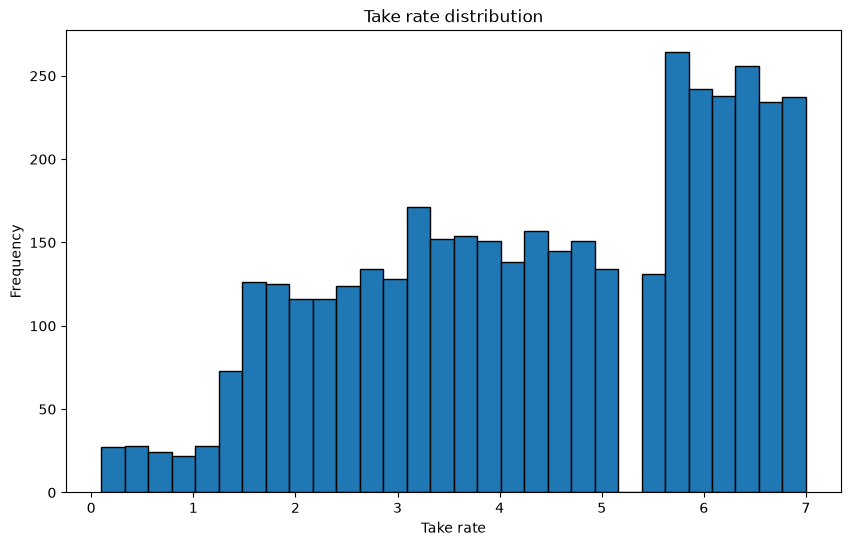

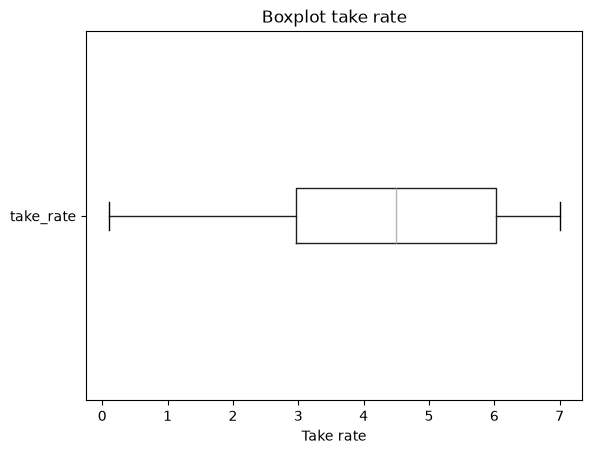

In [15]:
pdf_merchant = merchant_final.select("take_rate", "total_revenue").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf_merchant["take_rate"], bins=30, edgecolor="black")
plt.xlabel("Take rate")
plt.ylabel("Frequency")
plt.title("Take rate distribution")
plt.show()

pdf_merchant.boxplot(column="take_rate", vert=False, grid=False)
plt.xlabel("Take rate")
plt.title("Boxplot take rate")
plt.show()

## Merchant category trends

In [16]:
# average take rate by category
category_take_rate = (
    merchant_curated
    .groupBy("category")
    .agg(
        F.avg("take_rate").alias("avg_take_rate"),
        F.count("merchant_abn").alias("n_merchants")
    )
    .orderBy(F.desc("avg_take_rate"))
)
peek(category_take_rate, 10)

+-------------------------------------------------------------------------------------+------------------+-----------+
|category                                                                             |avg_take_rate     |n_merchants|
+-------------------------------------------------------------------------------------+------------------+-----------+
|furniture, home furnishings and equipment shops, and manufacturers, except appliances|4.730494505494508 |182        |
|music shops - musical instruments, pianos, and sheet music                           |4.6974251497005985|167        |
|gift, card, novelty, and souvenir shops                                              |4.655164835164834 |182        |
|lawn and garden supply outlets, including nurseries                                  |4.646405228758169 |153        |
|digital goods: books, movies, music                                                  |4.645384615384615 |195        |
|cable, satellite, and other pay television and 

In [17]:
# category with the highest total transaction volume and revenue
category_volume = (
    merchant_curated
    .groupBy("category")
    .agg(
        F.sum("n_transactions").alias("total_transactions"),
        F.sum("total_revenue").alias("total_revenue"),
        F.avg("avg_order_value").alias("avg_order_value")
    )
    .orderBy(F.desc("total_transactions"))
)

peek(category_volume, 10)

+-------------------------------------------------------------------------------------+------------------+--------------------+------------------+
|category                                                                             |total_transactions|total_revenue       |avg_order_value   |
+-------------------------------------------------------------------------------------+------------------+--------------------+------------------+
|tent and awning shops                                                                |1816892           |1.479018475898072E8 |570.1038100550433 |
|gift, card, novelty, and souvenir shops                                              |1640011           |1.1135403504686722E8|76.25643762999869 |
|digital goods: books, movies, music                                                  |1283753           |8.249520292525646E7 |71.30718345873865 |
|watch, clock, and jewelry repair shops                                               |1031475           |7.5444493335

In [18]:
# merchants with the highest take rate
top_take_rate_merchants = (
    merchant_curated
    .select("merchant_abn", "category", "take_rate", "n_transactions", "total_revenue")
    .orderBy(F.desc("take_rate"))
)
peek(top_take_rate_merchants, 10)

+------------+-------------------------------------------------------------------------------------+---------+--------------+------------------+
|merchant_abn|category                                                                             |take_rate|n_transactions|total_revenue     |
+------------+-------------------------------------------------------------------------------------+---------+--------------+------------------+
|96161808980 |digital goods: books, movies, music                                                  |7.0      |13540         |1150344.8388259746|
|40305723628 |computer programming , data processing, and integrated systems design services       |7.0      |688           |96787.16693522135 |
|57011992135 |computers, computer peripheral equipment, and software                               |7.0      |1900          |98011.03825094031 |
|99319455478 |watch, clock, and jewelry repair shops                                               |6.99     |524           |13900

In [19]:
# merchant bring the most profit (estimated profit = total revenue * take rate)
merchant_profit = (
    merchant_curated
    .withColumn("estimated_profit", F.col("total_revenue") * F.col("take_rate") / 100)
    .select("merchant_abn", "category", "take_rate", "total_revenue", "n_transactions", "estimated_profit")
    .orderBy(F.desc("estimated_profit"))
)
peek(merchant_profit, 10)

+------------+-------------------------------------------------------------------------------------+---------+-----------------+--------------+-----------------+
|merchant_abn|category                                                                             |take_rate|total_revenue    |n_transactions|estimated_profit |
+------------+-------------------------------------------------------------------------------------+---------+-----------------+--------------+-----------------+
|79827781481 |furniture, home furnishings and equipment shops, and manufacturers, except appliances|6.82     |9734168.478418225|4798          |663870.290228123 |
|48534649627 |opticians, optical goods, and eyeglasses                                             |6.64     |9408958.32074363 |66437         |624754.832497377 |
|32361057556 |gift, card, novelty, and souvenir shops                                              |6.61     |9434452.552354382|85780         |623617.3137106247|
|86578477987 |watch, clock, 

## Merchant size segmentation

In [20]:
merchant_curated = merchant_curated.withColumn(
    "merchant_size",
    F.when(F.col("n_transactions") >= 5000, "large_chain")
     .when(F.col("n_transactions") >= 500, "medium")
     .otherwise("small_boutique")
)
merchant_curated.groupBy("merchant_size").count().orderBy(F.desc("count")).show()

+--------------+-----+
| merchant_size|count|
+--------------+-----+
|small_boutique| 2178|
|        medium| 1300|
|   large_chain|  548|
+--------------+-----+



In [21]:
size_summary = (
    merchant_curated
    .groupBy("merchant_size")
    .agg(
        F.avg("take_rate").alias("avg_take_rate"),
        F.avg("avg_merchant_fraud_prob").alias("avg_merchant_fraud_prob"),
        F.avg("total_revenue").alias("avg_total_revenue"),
        F.avg("avg_order_value").alias("avg_order_value"),
        F.count("merchant_abn").alias("n_merchants")
    )
    .orderBy(F.desc("avg_total_revenue"))
)
peek(size_summary)

+--------------+------------------+-----------------------+------------------+------------------+-----------+
|merchant_size |avg_take_rate     |avg_merchant_fraud_prob|avg_total_revenue |avg_order_value   |n_merchants|
+--------------+------------------+-----------------------+------------------+------------------+-----------+
|large_chain   |4.552481751824816 |29.61695456887171      |2004847.262719792 |141.8722378671416 |548        |
|medium        |4.4778692307692305|50.25231238928743      |603851.2665925873 |381.7217926003611 |1300       |
|small_boutique|4.310674931129479 |53.66154746709815      |125524.72271583161|1879.9579174900732|2178       |
+--------------+------------------+-----------------------+------------------+------------------+-----------+

-> 3 rows total


## Fraud probability distribution analysis

In [22]:
# compare the number of unique merchant_abn in both sources
merchant_clean = spark.read.parquet("../data/curated/merchant/")

merchant_abn_in_parquet = merchant_clean.select("merchant_abn").distinct()
merchant_abn_in_fraud_csv = merchant_fraud.select("merchant_abn").distinct()

print(f"Unique number of merchant in curated merchant table: {merchant_abn_in_parquet.count()}")
print(f"Unique number of merchant in merchant_fraud_probability.csv: {merchant_abn_in_fraud_csv.count()}")

# Inner join to find the overlap of merchant_abn between the two sources
overlap = merchant_abn_in_parquet.join(merchant_abn_in_fraud_csv, on="merchant_abn", how="inner")
print(f"Number of merchant overlap: {overlap.count()}")

Unique number of merchant in curated merchant table: 4026
Unique number of merchant in merchant_fraud_probability.csv: 61
Number of merchant overlap: 48


In [23]:
merchant_fraud_stats = merchant_fraud.select(
    F.expr("percentile_approx(fraud_probability, array(0.5, 0.75, 0.90, 0.95, 0.99))").alias("percentiles"),
    F.mean("fraud_probability").alias("mean"),
    F.min("fraud_probability").alias("min"),
    F.max("fraud_probability").alias("max"),
)
merchant_fraud_stats.show(truncate=False)

+----------------------------------------------------------------------------------------------+------------------+-----------------+----------------+
|percentiles                                                                                   |mean              |min              |max             |
+----------------------------------------------------------------------------------------------+------------------+-----------------+----------------+
|[32.3890854385705, 48.642698518841016, 67.1177397510102, 72.73069736562613, 91.09606847149965]|40.419334695018094|18.21089142894488|94.1347004808891|
+----------------------------------------------------------------------------------------------+------------------+-----------------+----------------+



In [24]:
# split train and test data based on the availability of the label (avg_fraud_probability)
train_df = merchant_curated.filter(F.col("avg_merchant_fraud_prob").isNotNull())
predict_df = merchant_curated 

print(f"Number of merchant that has label (train set): {train_df.count()}")
print(f"Total merchant (predict set): {predict_df.count()}")

Number of merchant that has label (train set): 48


Total merchant (predict set): 4026
